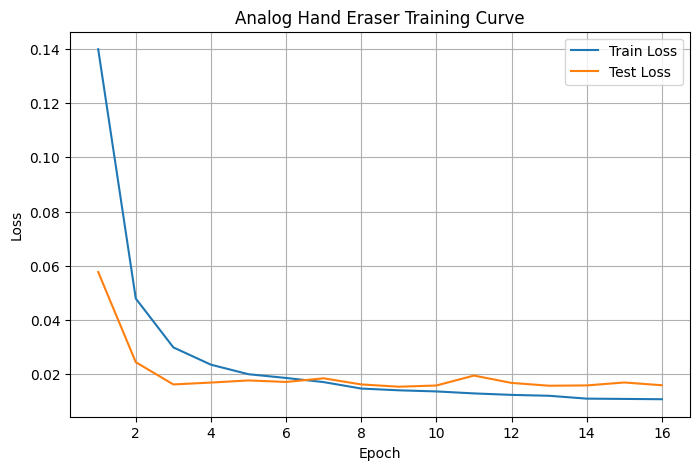

In [3]:
import json
import matplotlib.pyplot as plt

history_path = "outputs/eraser_history.json"

# Load training history
with open(history_path, "r") as f:
    history = json.load(f)

epochs = [item["epoch"] for item in history]
train_losses = [item["train_loss"] for item in history]
test_losses = [item["test_loss"] for item in history]

# Plot the training curve
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Analog Hand Eraser Training Curve")
plt.legend()
plt.grid(True)
plt.show()

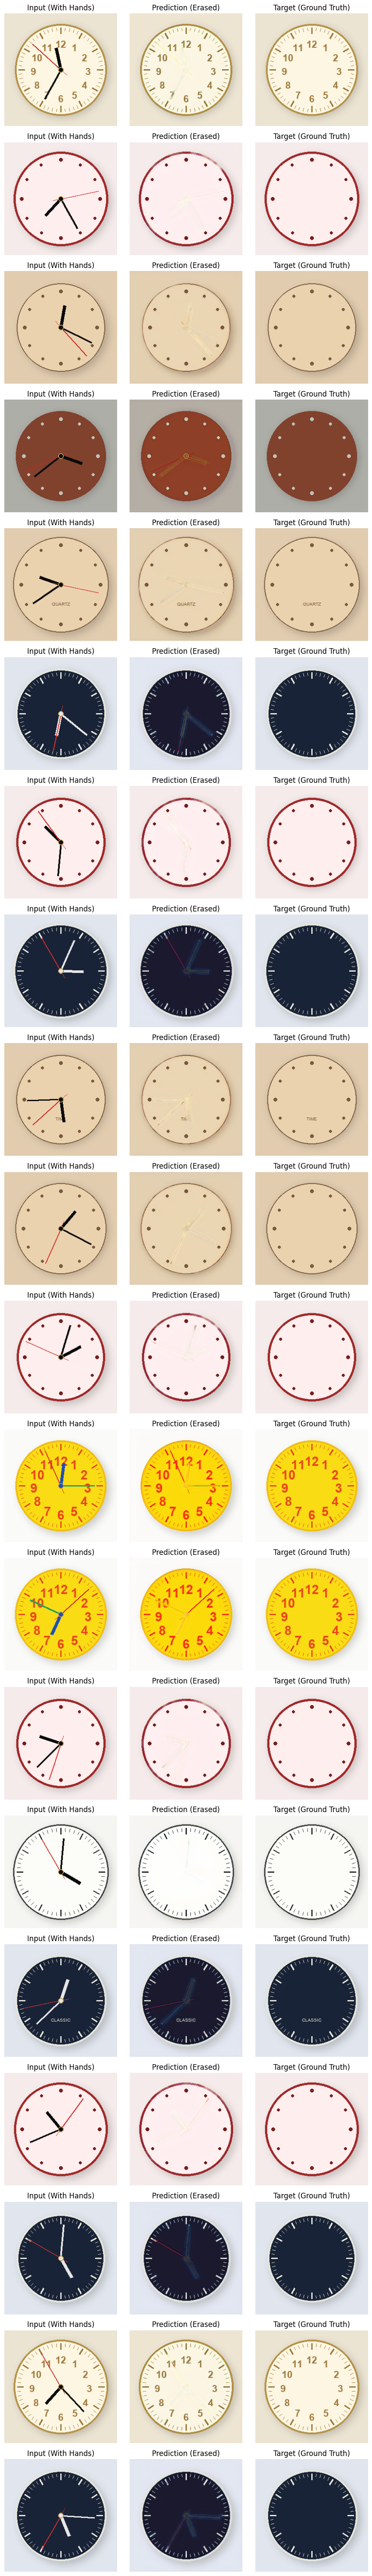

In [4]:
import torch
import random
from train_eraser import SmallUNet, ClockEraserDataset, transform, TEST_CSV, device

# Load the dataset
test_dataset = ClockEraserDataset(TEST_CSV, transform=transform)

# Load the best trained model
best_model_path = "outputs/checkpoints/best_eraser_unet.pth"
model = SmallUNet().to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

def show_predictions(model, dataset, device, num_samples=4):
    """
    Display random input, model prediction, and target images.
    """
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    fig, axes = plt.subplots(len(indices), 3, figsize=(9, 3 * len(indices)))
    
    if len(indices) == 1:
        axes = [axes]

    with torch.no_grad():
        for row_index, sample_index in enumerate(indices):
            input_tensor, target_tensor = dataset[sample_index]
            
            # Predict
            pred_tensor = model(input_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()
            
            # Convert tensors to numpy arrays for plotting
            input_img = input_tensor.permute(1, 2, 0).numpy()
            pred_img = pred_tensor.permute(1, 2, 0).numpy()
            target_img = target_tensor.permute(1, 2, 0).numpy()

            axes[row_index][0].imshow(input_img)
            axes[row_index][0].set_title("Input (With Hands)")
            axes[row_index][0].axis("off")

            axes[row_index][1].imshow(pred_img)
            axes[row_index][1].set_title("Prediction (Erased)")
            axes[row_index][1].axis("off")
            
            axes[row_index][2].imshow(target_img)
            axes[row_index][2].set_title("Target (Ground Truth)")
            axes[row_index][2].axis("off")

    plt.tight_layout()
    plt.show()

# Show random samples
show_predictions(model, test_dataset, device, num_samples=20)